# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

#### This notebook builds F2 and F3 level models from the corpus to explore parts of speech.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Imports

In [2]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
%%capture
%run notebooks/create_tables.ipynb

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Compute Parts of Speech

In [4]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))
VOCAB['max_pos'] = CORPUS[['term_str','pos']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['max_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack(fill_value=0).idxmax(1)

VOCAB.head()

n         p         i      p_yr      i_yr  n_pos_group  \
year term_str                                                              
2013 the       4963  0.009662  6.693500  0.059097  4.080779            2   
     of        3106  0.006047  7.369654  0.036985  4.756933            3   
     and       2631  0.005122  7.609101  0.031329  4.996380            2   
     in        2310  0.004497  7.796819  0.027506  5.184098            2   
     to        1710  0.003329  8.230716  0.020362  5.617995            2   

              cat_pos_group  n_pos       cat_pos max_pos max_pos_group  
year term_str                                                           
2013 the           {VB, DT}      2     {VBP, DT}      DT            DT  
     of        {CC, NN, IN}      3  {CC, NN, IN}      IN            IN  
     and           {CC, NN}      2     {CC, NNP}      CC            CC  
     in            {NN, IN}      2     {NNP, IN}      IN            IN  
     to            {TO, NN}      2     {TO, NNP}      TO            TO

### Add POS Ambiguity

In [5]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))

### Reproduce finding about ambiguous words

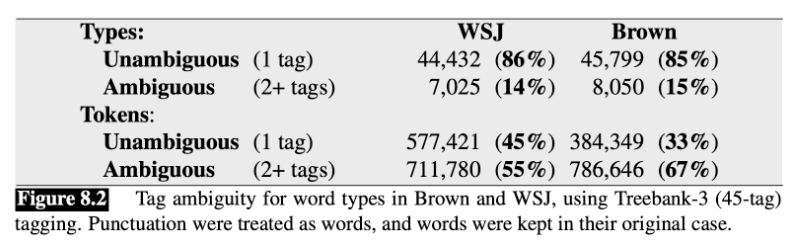

In [6]:
# Group by number of parts of speech when greater than or equal to 2
# And aggregate by count and sum
Q = VOCAB.groupby(VOCAB.n_pos >= 2).agg({'n': ['count','sum']})
# Make into percentages
Q = ((Q / Q.sum()) * 100).round().astype(int)
# Find the (un)ambiguity for types and for tokens
Q.columns = ['climate corpus types', 'climate corpus tokens']
Q.index = ['unambiguous','ambiguous']
Q.style.background_gradient()

,climate corpus types,climate corpus tokens
unambiguous,67,27
ambiguous,33,73


In [7]:
# Add WSJ and Brown information
new_cols = ['wsj corpus types', 'wsj corpus tokens', 'brown corpus types', 'brown corpus tokens']
new = pd.DataFrame(columns = new_cols).astype('float')
Q_tot = pd.concat([Q, new])

# Ading WSJ types
Q_tot.loc['unambiguous', 'wsj corpus types'] = 86
Q_tot.loc['ambiguous', 'wsj corpus types'] = 14

# Adding WSJ tokens
Q_tot.loc['unambiguous', 'wsj corpus tokens'] = 45
Q_tot.loc['ambiguous', 'wsj corpus tokens'] = 55

# Repeat for Brown
Q_tot.loc['unambiguous', 'brown corpus types'] =85
Q_tot.loc['ambiguous', 'brown corpus types'] = 15
Q_tot.loc['unambiguous', 'brown corpus tokens'] = 33
Q_tot.loc['ambiguous', 'brown corpus tokens'] = 67

Q_tot.style.background_gradient()

,climate corpus types,climate corpus tokens,wsj corpus types,wsj corpus tokens,brown corpus types,brown corpus tokens
unambiguous,67.000000,27.000000,86.000000,45.000000,85.000000,33.000000
ambiguous,33.000000,73.000000,14.000000,55.000000,15.000000,67.000000


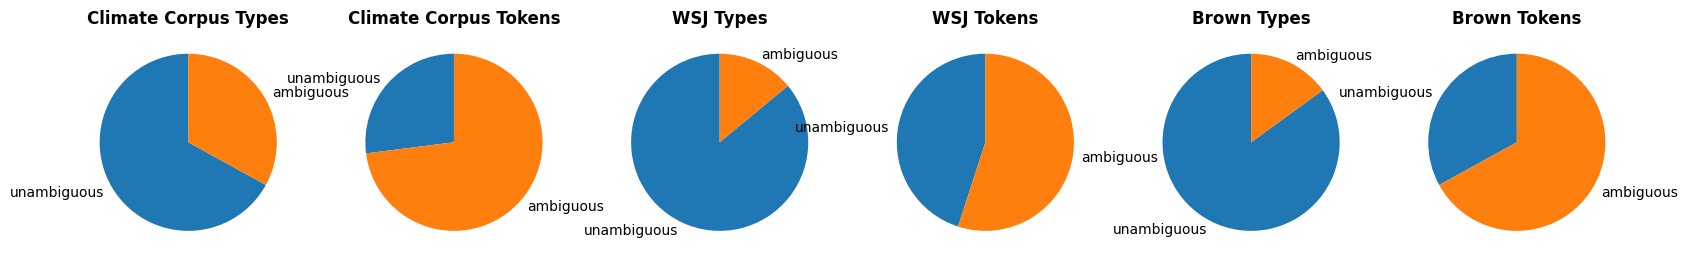

In [8]:
ax = Q_tot.plot.pie(subplots=True, legend=False, startangle=90, figsize=(20,8))
# No Y labels
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')
ax[4].set_ylabel('')
ax[5].set_ylabel('')
# Plot climate corpus as well as WSJ and Brown findings
ax[0].set_title('Climate Corpus Types', fontweight='bold')
ax[1].set_title('Climate Corpus Tokens', fontweight='bold')
ax[2].set_title('WSJ Types', fontweight='bold')
ax[3].set_title('WSJ Tokens', fontweight='bold')
ax[4].set_title('Brown Types', fontweight='bold')
ax[5].set_title('Brown Tokens', fontweight='bold')
plt.show()

Next, I explored parts of speech in pos.ipynb. I found some interesting differences from typical pos patterns in my corpus. For example, in the plot below, the climate corpus has more ambiguous types AND tokens as compared to WSJ and Brown. I wonder if this observation is connected to the fact that the WSJ and Brown come from editorial sources, while scientific definitions may have more ambiguity/multiple meanings, though this does frankly go against my conception of science as having singular definitions.


In [9]:
VOCAB.loc[(VOCAB.n_pos == 1) & (VOCAB.max_pos.str.match('(VB|NN)'))].sample(10)

n         p          i      p_yr       i_yr  n_pos_group  \
year term_str                                                                  
2023 segmentation   1  0.000002  18.970496  0.000004  17.864035            1   
     highorder      1  0.000002  18.970496  0.000004  17.864035            1   
2013 coal           1  0.000002  18.970496  0.000012  16.357775            1   
2023 expertise     10  0.000019  15.648568  0.000042  14.542107            1   
     lwang          2  0.000004  17.970496  0.000008  16.864035            1   
     centimeter     1  0.000002  18.970496  0.000004  17.864035            1   
     nars           1  0.000002  18.970496  0.000004  17.864035            1   
2018 epipactis      1  0.000002  18.970496  0.000005  17.544172            1   
2023 allertop20     1  0.000002  18.970496  0.000004  17.864035            1   
2013 pall           1  0.000002  18.970496  0.000012  16.357775            1   

                  cat_pos_group  n_pos cat_pos max_pos max_pos_group  
year term_str                                                         
2023 segmentation          {NN}      1    {NN}      NN            NN  
     highorder             {NN}      1    {NN}      NN            NN  
2013 coal                  {NN}      1    {NN}      NN            NN  
2023 expertise             {NN}      1    {NN}      NN            NN  
     lwang                 {NN}      1   {NNP}     NNP            NN  
     centimeter            {NN}      1    {NN}      NN            NN  
     nars                  {NN}      1   {NNP}     NNP            NN  
2018 epipactis             {NN}      1   {NNP}     NNP            NN  
2023 allertop20            {NN}      1   {NNP}     NNP            NN  
2013 pall                  {NN}      1   {NNP}     NNP            NN

In [10]:
VOCAB.loc[(VOCAB.n_pos >= 2) & (VOCAB.max_pos.str.match('(VB|NN)'))].sample(10)

n         p          i      p_yr       i_yr  n_pos_group  \
year term_str                                                                
2018 drains       2  0.000004  17.970496  0.000010  16.544172            2   
2013 overlapped   2  0.000004  17.970496  0.000024  15.357775            2   
2018 moist        3  0.000006  17.385534  0.000016  15.959210            2   
2013 begin       31  0.000060  14.016300  0.000369  11.403579            4   
2018 pudu         6  0.000012  16.385534  0.000031  14.959210            1   
     colder       2  0.000004  17.970496  0.000010  16.544172            2   
2023 indicator    5  0.000010  16.648568  0.000021  15.542107            2   
     australis    1  0.000002  18.970496  0.000004  17.864035            2   
2013 weighting    1  0.000002  18.970496  0.000012  16.357775            2   
2023 harvested    5  0.000010  16.648568  0.000021  15.542107            2   

                    cat_pos_group  n_pos                      cat_pos max_pos  \
year term_str                                                                   
2018 drains              {NN, VB}      2                   {VBZ, NNS}     NNS   
2013 overlapped          {JJ, VB}      2                    {JJ, VBD}     VBD   
2018 moist               {NN, VB}      3                {NN, NNP, VB}      NN   
2013 begin       {SY, JJ, NN, VB}      6  {NN, NNP, JJ, VBP, SYM, VB}      VB   
2018 pudu                    {NN}      2                    {NN, NNP}      NN   
     colder              {NN, VB}      2                     {NN, VB}      NN   
2023 indicator           {NN, VB}      2                     {NN, VB}      NN   
     australis           {RB, NN}      2                     {RB, NN}      NN   
2013 weighting           {NN, VB}      3               {NN, NNP, VBG}      NN   
2023 harvested           {JJ, VB}      3               {JJ, VBN, VBD}     VBN   

                max_pos_group  
year term_str                  
2018 drains                NN  
2013 overlapped            VB  
2018 moist                 NN  
2013 begin                 VB  
2018 pudu                  NN  
     colder                NN  
2023 indicator             NN  
     australis             NN  
2013 weighting             NN  
2023 harvested             VB

### Saving to CSV

In [11]:
VOCAB.to_csv("csvs/VOCAB/VOCAB_pos.csv")
print(len(VOCAB))

40776
